**practica #3:**

**Series de Fourier: magnitud y fase**

**presentado por:**
Karly Tarazona, Luis Montoya 



**procedimiento:**

a) Construya una señal cuadrada periódica, definiendo su frecuencia fundamental, amplitud y número de muestras.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
import numpy as np
import matplotlib.pyplot as plt

f0 = 5
A = 1
N = 5000

T0 = 1 / f0
num_periodos = 1

t = np.linspace(0, num_periodos * T0, N, endpoint=False)

x_cuadrada = A * np.where(np.sin(2 * np.pi * f0 * t) >= 0,1,-1)



b) Construya una señal triangular periódica, con la misma frecuencia fundamental, amplitud y número de muestras que la señal anterior.

In [3]:

x_triangular = A * (2 / np.pi) * np.arcsin(np.sin(2 * np.pi * f0 * t))


c) Grafique ambas señales en el dominio del tiempo.

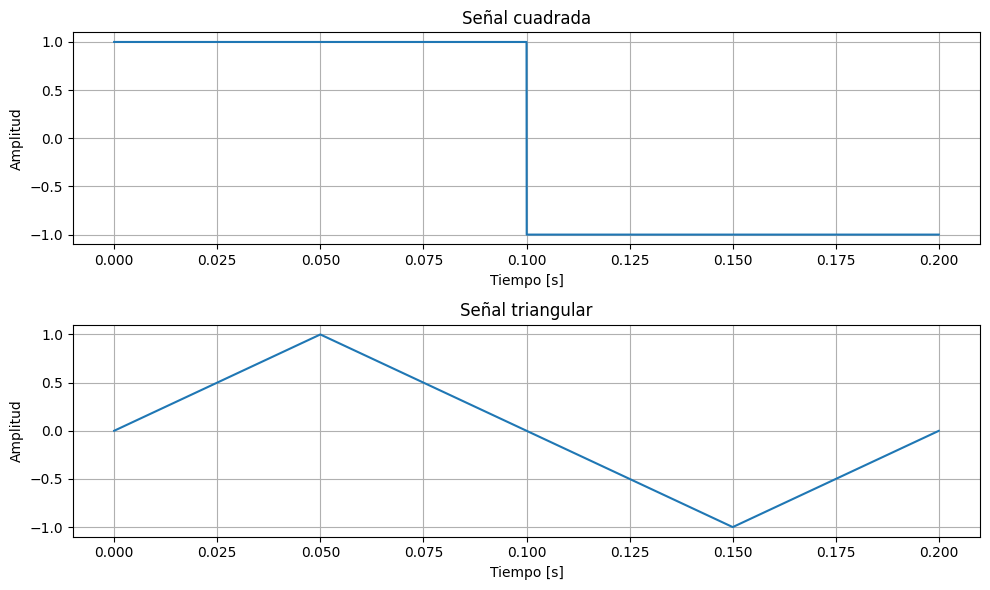

In [4]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x_cuadrada)
plt.title("Señal cuadrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, x_triangular)
plt.title("Señal triangular")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

d) Cree una función que reciba una señal periódica, y devuelva sus coeficientes de la serie de Fourier (forma exponencial), calculados mediante NumPy.

In [5]:
def coeficientes_fourier(x):
    N = len(x)
    
    # Transformada rápida de Fourier
    C = np.fft.fft(x)
    
    # Normalización
    C = C / N
    
    # Reorganizar las frecuencias
    C = np.fft.fftshift(C)
    
    return C



e) Aplique la función anterior a la señal cuadrada y a la señal triangular, y obtenga sus respectivos coeficientes.

In [6]:
C_cuadrada = coeficientes_fourier(x_cuadrada)

C_triangular = coeficientes_fourier(x_triangular)

print(f"C_cuadrada: {C_cuadrada}")
print(f"C_triangular: {C_triangular}")

C_cuadrada: [ 4.00000000e-04+0.00000000e+00j -9.81665025e-19+2.51327445e-07j
  4.00000000e-04+0.00000000e+00j ...  2.93032842e-18-7.53983130e-07j
  4.00000000e-04+0.00000000e+00j  1.12585616e-18-2.51327445e-07j]
C_triangular: [-5.24925464e-19-3.15544362e-34j -9.89964776e-19-1.60000063e-07j
 -1.02253912e-18+4.66509493e-19j ...  1.14233889e-18-1.60000569e-07j
 -1.02253912e-18-4.66509493e-19j -1.18622577e-18+1.60000063e-07j]


f) Cree una función que reciba un conjunto de coeficientes de Fourier y grafique el espectro de magnitud y el espectro de fase correspondientes.

In [7]:

frecuencias = np.fft.fftshift(np.fft.fftfreq(N, d=t[1]-t[0]))
def graficar_espectros(C, frecuencias, titulo):
    
    # Calcular magnitud y fase
    magnitud = np.abs(C)
    fase = np.angle(C)
    fase[magnitud < 1e-3 * magnitud.max()] = 0
   
    
    # Crear figura
    plt.figure(figsize=(10, 6))
    
    # -------------------------
    # Espectro de magnitud
    # -------------------------
    plt.subplot(2, 1, 1)
    plt.stem(frecuencias, magnitud)
    plt.xlim(-60, 60)
    plt.title("Espectro de magnitud - " + titulo)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|C_k|")
    plt.grid(True)
    
    # -------------------------
    # Espectro de fase
    # -------------------------
    plt.subplot(2, 1, 2)
    plt.stem(frecuencias, fase)
    plt.xlim(-60, 60)
    plt.title("Espectro de fase - " + titulo)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Fase [rad]")
    plt.grid(True)
    
    # Ajustar espacios
    plt.tight_layout()
    
    # Mostrar
    plt.show()


g) Grafique los espectros de magnitud y fase de la señal cuadrada y de la señal triangular.

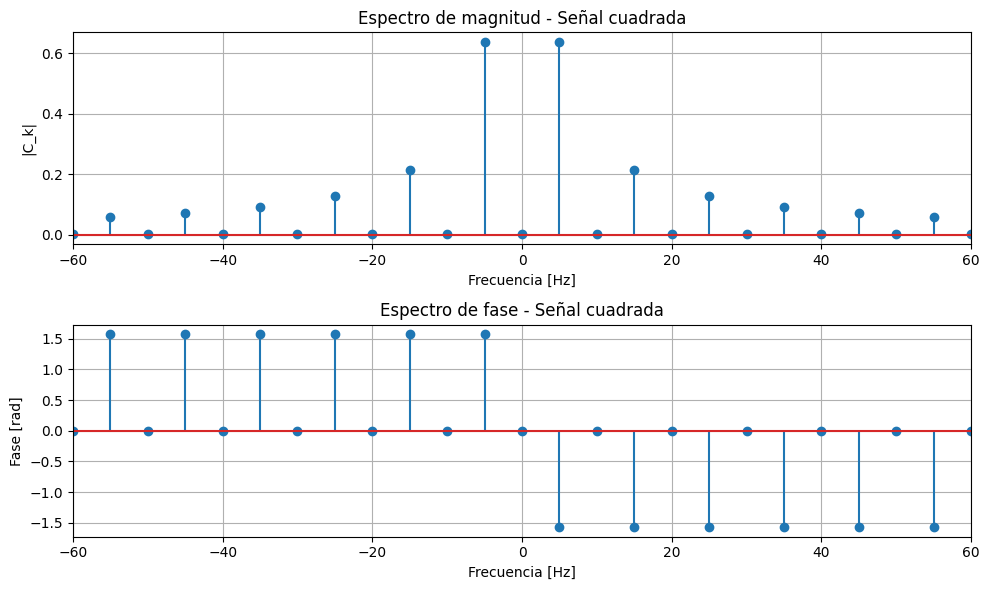

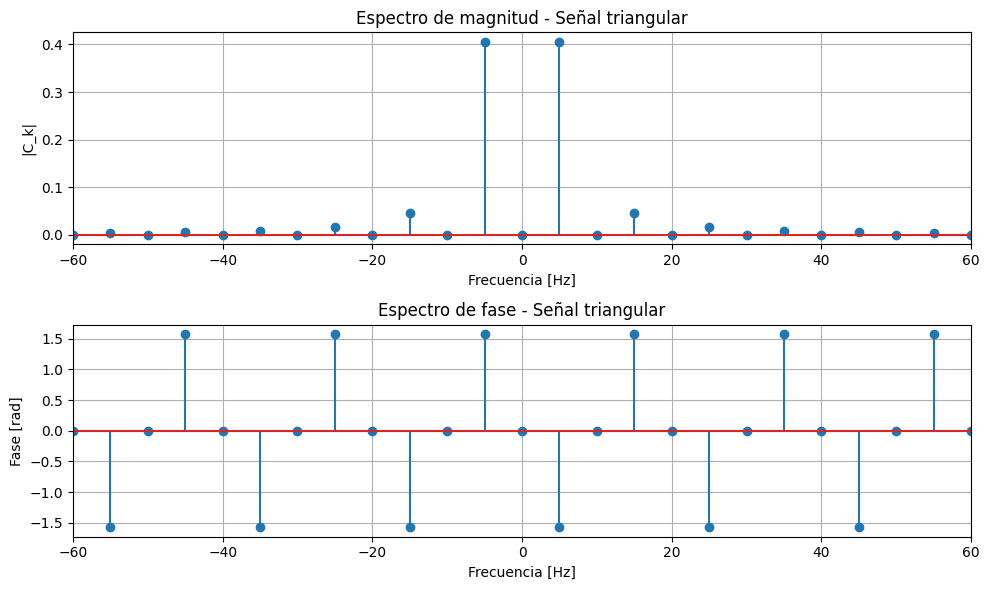

In [8]:
graficar_espectros(C_cuadrada,frecuencias,"Señal cuadrada")

graficar_espectros(C_triangular,frecuencias,"Señal triangular")

h) Cree una función que reconstruya una señal a partir de una suma de senos (armónicos), recibiendo como parámetros los coeficientes de Fourier y el número de armónicos a utilizar.

In [9]:
def reconstruir_señal(C, t, f0, num_armonicos):
    
    N = len(C)
    
    # Índices de los coeficientes
    k = np.arange(-N//2, N//2)
    
    # Frecuencia angular fundamental
    w0 = 2 * np.pi * f0
    
    # Señal reconstruida
    x_reconstruida = np.zeros(len(t), dtype=complex)
    
    # Seleccionar los armónicos
    for i in range(len(k)):
        
        if abs(k[i]) <= num_armonicos:
            
            x_reconstruida += C[i] * np.exp(
                1j * k[i] * w0 * t
            )
    
    # Como la señal original es real,
    # tomamos la parte real
    return np.real(x_reconstruida)



i) Reconstruya la señal cuadrada y la señal triangular utilizando N = 1, 3, 5, 20 y 50 armónicos, y grafique cada reconstrucción junto con la señal original.

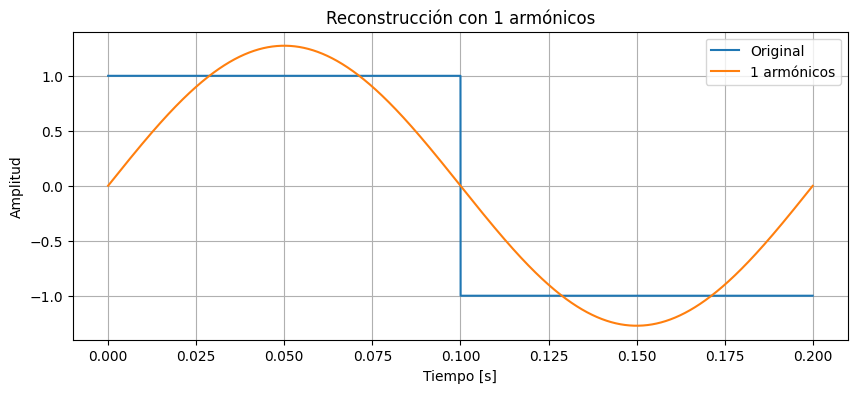

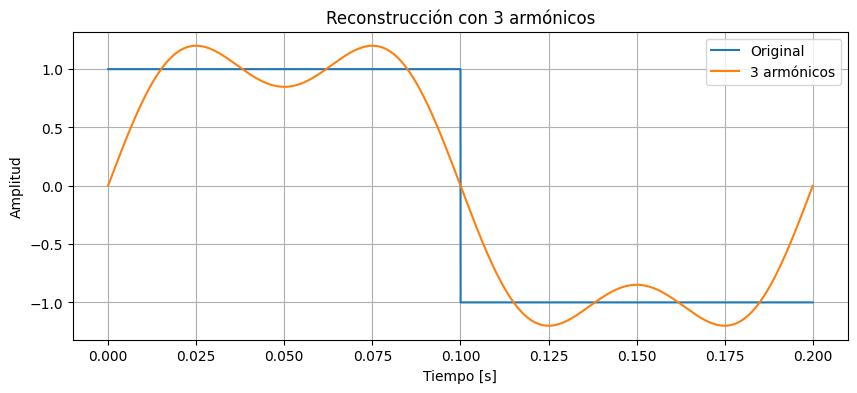

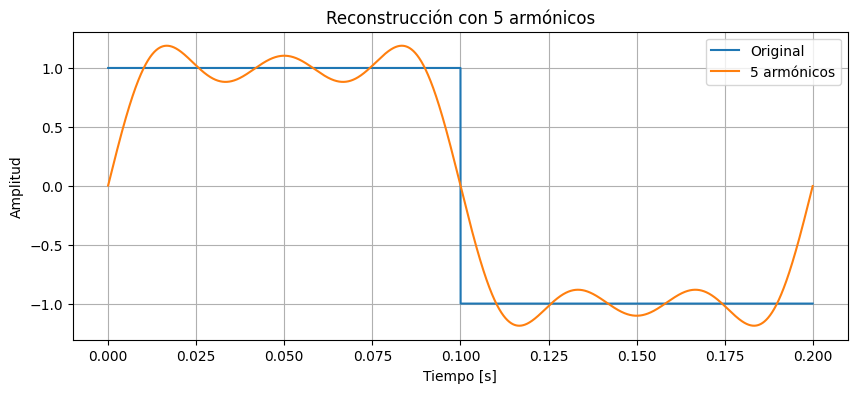

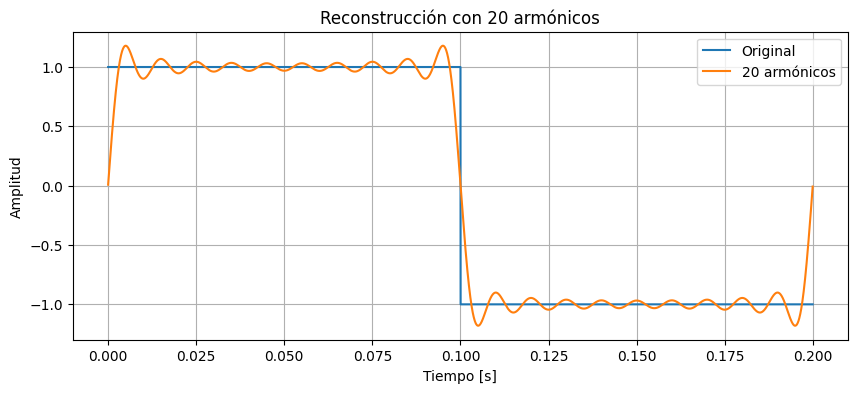

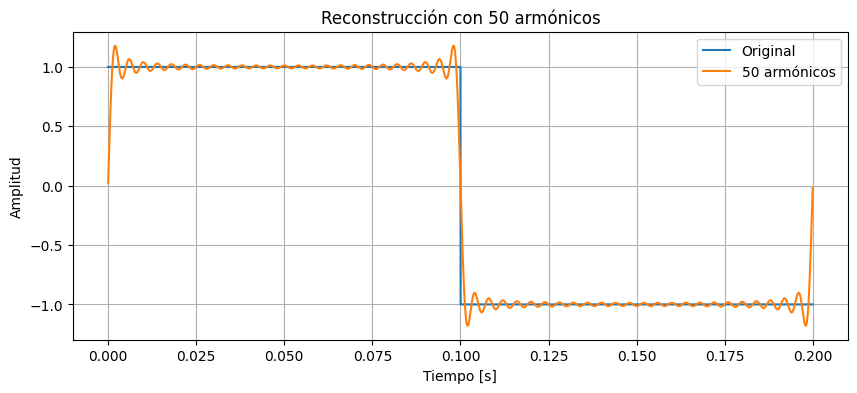

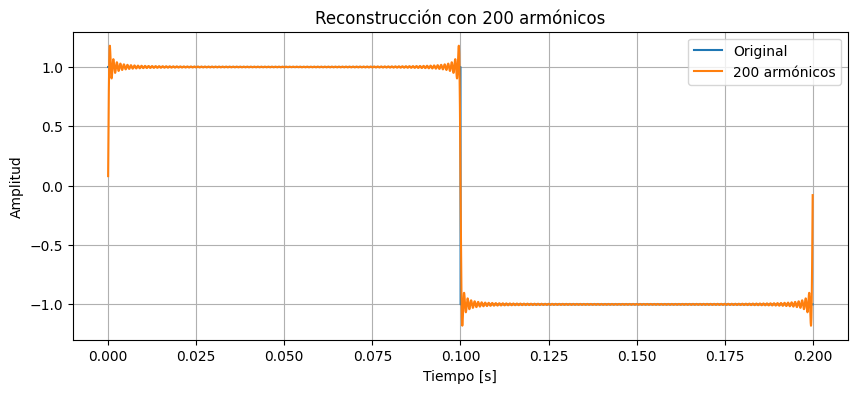

In [10]:
C_cuadrada = coeficientes_fourier(x_cuadrada)

armonicos = [1, 3, 5, 20, 50, 200]

for n in armonicos:

    x_reconstruida = reconstruir_señal(C_cuadrada,t,f0,n)

    plt.figure(figsize=(10, 4))

    plt.plot(t, x_cuadrada, label="Original")
    plt.plot(t, x_reconstruida, label=f"{n} armónicos")

    plt.title(f"Reconstrucción con {n} armónicos")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()

    plt.show()


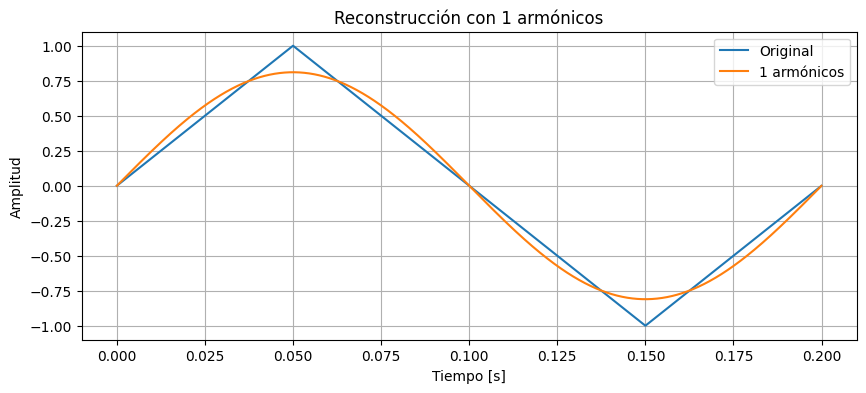

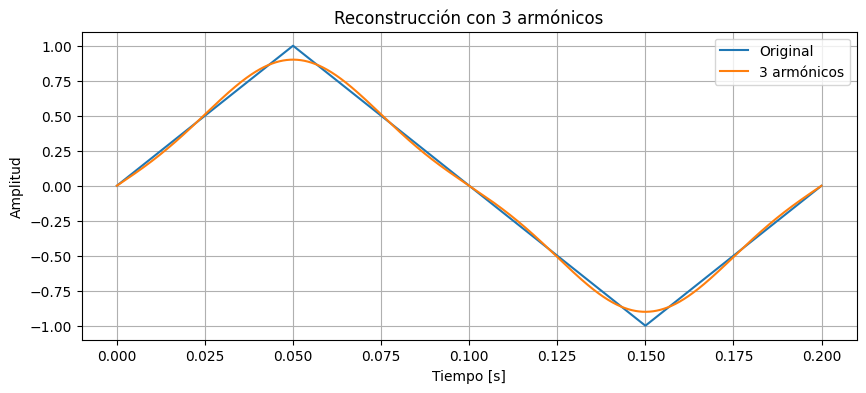

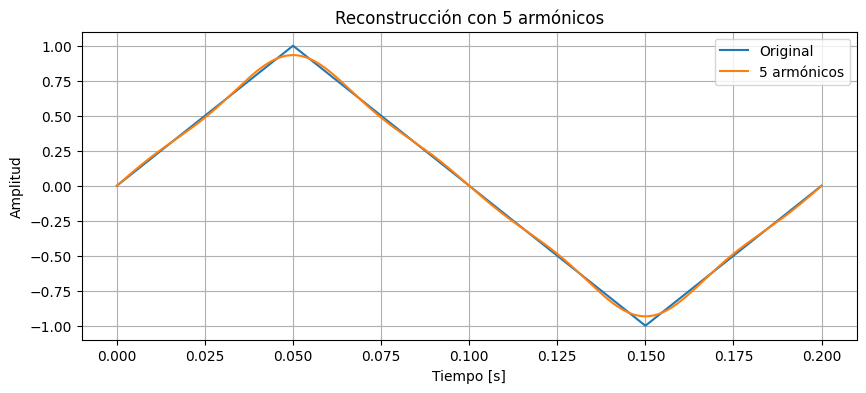

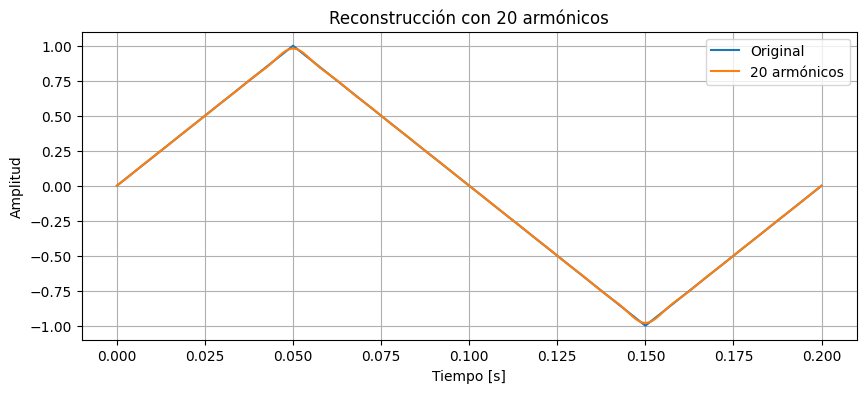

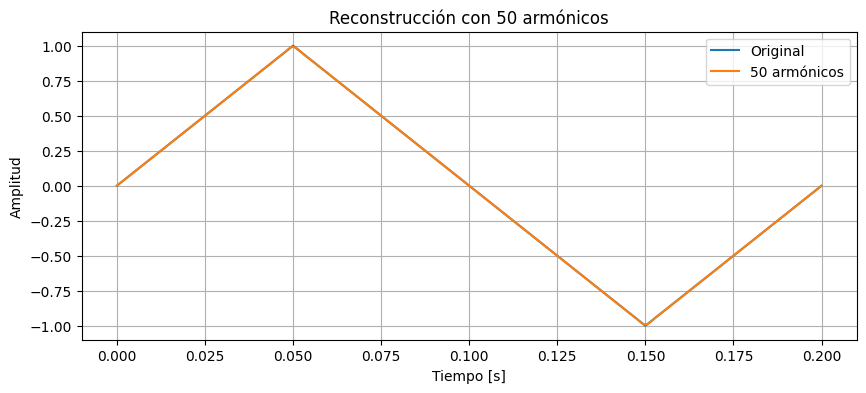

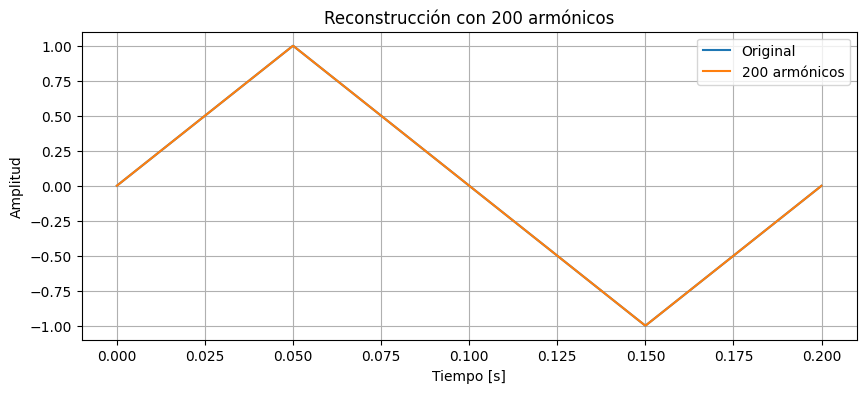

In [11]:

for n in armonicos:
    
    x_reconstruida = reconstruir_señal(C_triangular,t,f0,n)
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(t, x_triangular, label="Original")
    plt.plot(t, x_reconstruida, label=f"{n} armónicos")
    
    plt.title(f"Reconstrucción con {n} armónicos")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    
    plt.show()

j) Consulte, analice y describa el fenómeno de Gibbs observado en las reconstrucciones de la señal cuadrada.

El fenómeno de Gibbs se presenta durante la reconstrucción de la señal cuadrada mediante una cantidad finita de armónicos de Fourier. La señal cuadrada posee discontinuidades debido a sus cambios bruscos entre sus niveles de amplitud. Al aproximar estos cambios mediante una suma limitada de componentes sinusoidales, aparecen oscilaciones alrededor de las discontinuidades.

Al aumentar progresivamente el número de armónicos utilizados en la reconstrucción, por ejemplo de 1, 3, 5, 20 hasta 50 armónicos, la señal reconstruida se aproxima cada vez más a la señal cuadrada original. Sin embargo, las oscilaciones cercanas a los puntos de discontinuidad no desaparecen completamente. En cambio, se concentran en una región cada vez más pequeña alrededor del salto.

Este comportamiento corresponde al fenómeno de Gibbs. Por lo tanto, aumentar el número de armónicos mejora la aproximación de la señal en la mayor parte del período, pero no elimina completamente el sobrepico que aparece cerca de las discontinuidades. Este fenómeno es característico de la reconstrucción mediante series de Fourier de señales que presentan cambios abruptos (Jerri, A. J, 1998). 

K) Cargue una señal ECG sin ruido y su composición espectral. Consulte y describa brevemente los componentes de frecuencia principales asociados a las ondas P, al complejo QRS y a la onda T.

Frecuencia de muestreo: 360 Hz
Duración total: 1805.5555555555557 segundos
Segmento analizado: 10 segundos
Número de muestras: 3600


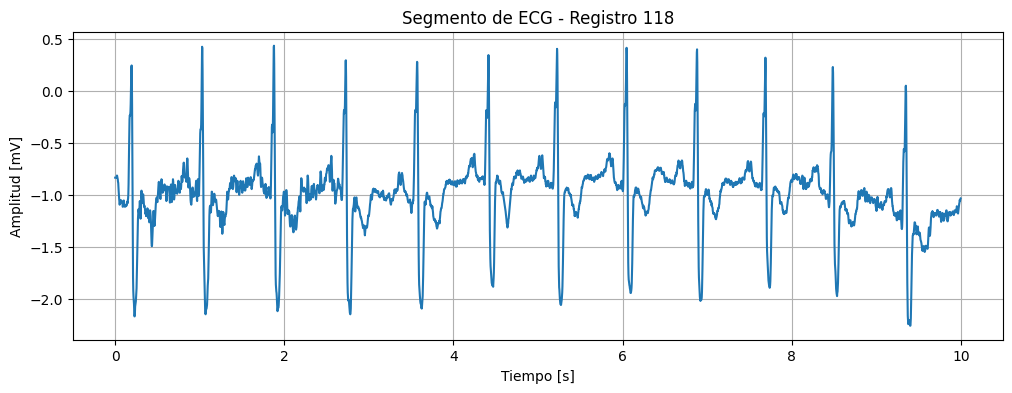

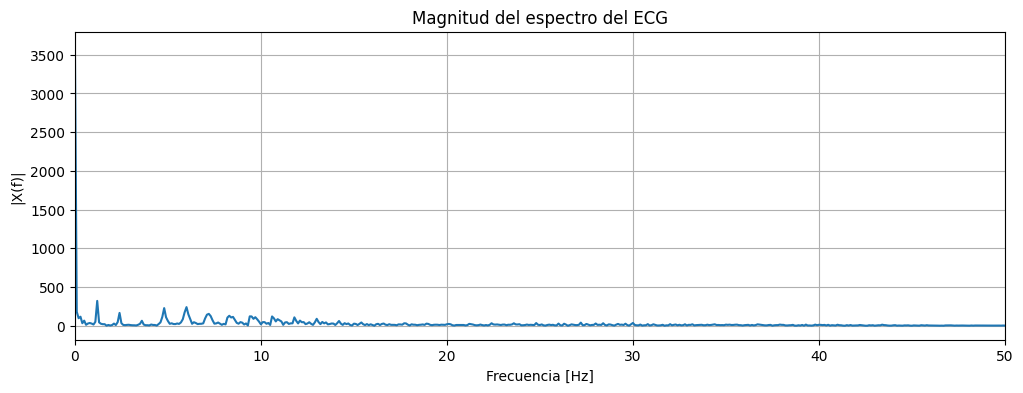

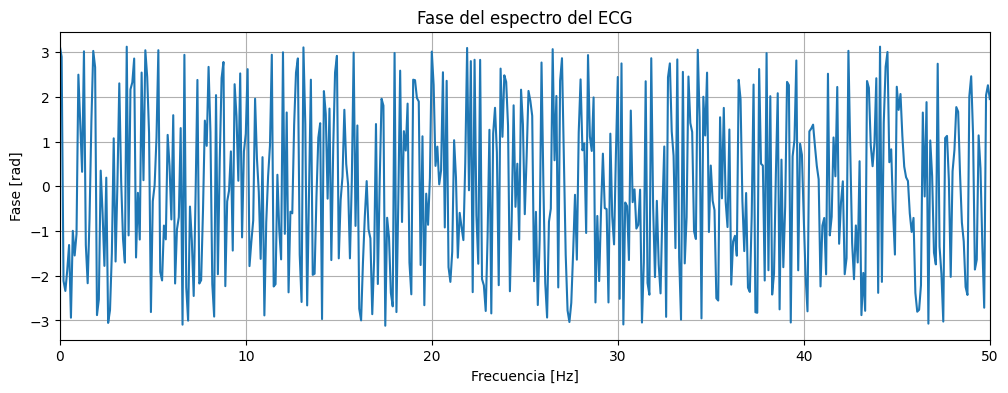

In [14]:
import wfdb
import shutil

# Preparar los archivos
shutil.copy("118.hea.txt", "118.hea")

# Cargar el registro
senal, info = wfdb.rdsamp("118")

# Frecuencia de muestreo
fs = info["fs"]

# Tomar el primer canal
ecg_completo = senal[:, 0]

print("Frecuencia de muestreo:", fs, "Hz")
print("Duración total:", len(ecg_completo) / fs, "segundos")



# Recortar un segmento de 10 segundos
duracion = 10  

N = int(duracion * fs)

ecg = ecg_completo[:N]


t = np.arange(len(ecg)) / fs

print("Segmento analizado:", duracion, "segundos")
print("Número de muestras:", len(ecg))


# Graficar el segmento de ECG
plt.figure(figsize=(12, 4))

plt.plot(t, ecg)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.title("Segmento de ECG - Registro 118")
plt.grid()

plt.show()

# Transformada de Fourier


X = np.fft.fft(ecg)

# Frecuencias correspondientes a cada coeficiente
frecuencias = np.fft.fftfreq(N, d=1/fs)

# Magnitud
magnitud = np.abs(X)

# Fase
fase = np.angle(X)


# 5. Seleccionar rango de frecuencias


mask = frecuencias >= 0

frecuencias_pos = frecuencias[mask]
magnitud_pos = magnitud[mask]
fase_pos = fase[mask]

mask_50 = frecuencias_pos <= 50

frecuencias_pos = frecuencias_pos[mask_50]
magnitud_pos = magnitud_pos[mask_50]
fase_pos = fase_pos[mask_50]


# Graficar magnitud


plt.figure(figsize=(12, 4))

plt.plot(frecuencias_pos, magnitud_pos)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.title("Magnitud del espectro del ECG")
plt.xlim(0, 50)
plt.grid()

plt.show()

# Graficar fase


plt.figure(figsize=(12, 4))

plt.plot(frecuencias_pos, fase_pos)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.title("Fase del espectro del ECG")
plt.xlim(0, 50)
plt.grid()

plt.show()

Las señales de un electrocardiograma (ECG) abarcan un rango de frecuencias generales entre 0.05 Hz y 100 Hz, donde cada onda específica se asocia predominantemente a una banda de frecuencia según la velocidad de los cambios eléctricos:

Onda T (repolarización ventricular): Se asocia a frecuencias bajas, principalmente entre 0 y 10 Hz, debido a la lentitud relativa del proceso de relajación del músculo cardíaco (Klabunde, 2023).

Onda P (despolarización auricular): Contiene frecuencias intermedias, ubicadas por lo general entre 5 y 30 Hz, reflejando la activación de la masa muscular menor de las aurículas (University of Toronto BioSec.Lab, 2010).

Complejo QRS (despolarización ventricular): Concentra las frecuencias más altas de la onda estándar, habitualmente entre 8 y 50 Hz, ya que representa un cambio eléctrico muy rápido y potente en los ventrículos. Las alteraciones o anomalías de conducción ventricular pueden rebasar los 70 Hz(Neural Cloud Solutions Inc., 2026).

En el siguiente gráfico se tienen las frecuencias aproximadas consultadas que corresponden a las ondas del ECG:

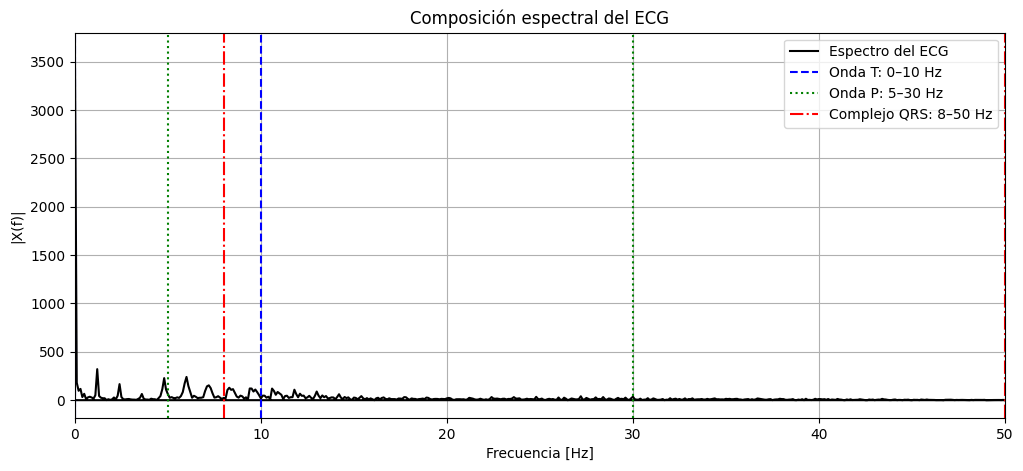

In [15]:
plt.figure(figsize=(12, 5))

# Espectro del ECG
plt.plot(
    frecuencias,
    magnitud,
    label="Espectro del ECG",
    color="black"
)

# ------------------------------------------------------------
# Onda T: 0 - 10 Hz
# ------------------------------------------------------------

plt.axvline(
    0,
    color="blue",
    linestyle="--",
    label="Onda T: 0–10 Hz"
)

plt.axvline(
    10,
    color="blue",
    linestyle="--"
)

# ------------------------------------------------------------
# Onda P: 5 - 30 Hz
# ------------------------------------------------------------

plt.axvline(
    5,
    color="green",
    linestyle=":",
    label="Onda P: 5–30 Hz"
)

plt.axvline(
    30,
    color="green",
    linestyle=":"
)

# ------------------------------------------------------------
# Complejo QRS: 8 - 50 Hz
# ------------------------------------------------------------

plt.axvline(
    8,
    color="red",
    linestyle="-.",
    label="Complejo QRS: 8–50 Hz"
)

plt.axvline(
    50,
    color="red",
    linestyle="-."
)

# ------------------------------------------------------------
# Configuración
# ------------------------------------------------------------

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.title("Composición espectral del ECG")
plt.xlim(0, 50)
plt.grid()

plt.legend()

plt.show()

**Bibliografía**

1. Jerri, A. J. (1998). The Gibbs Phenomenon in Fourier Analysis, Splines and Wavelet Approximations. Kluwer Academic Publishers.

2. Klabunde, R. E. (2023, November 1). *Electrocardiogram (EKG, ECG).* CV Physiology. https://cvphysiology.com/arrhythmias/a009

3. University of Toronto BioSec.Lab. (2010). *Heart biometrics fundamentals.* University of Toronto. https://www.comm.utoronto.ca/~biometrics/medical/heart-biometrics-fundamentals.html

4. Neural Cloud Solutions Inc. (2026). *Identify components of ECG: The PQRST wave explained.* The Neural Cloud. https://www.theneuralcloud.com/post/identify-components-of-ecg-the-pqrst-wave-explained